In [ ]:
# 1. Install Kaggle library
!pip install -q kaggle

In [ ]:
# 2. Securely input your Kaggle token (paste your KGAT_... token when prompted)
import os
import getpass
print("KGAT_51b023a80af8d470f35e9f7d4c37d782")
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass()

KGAT_51b023a80af8d470f35e9f7d4c37d782
··········


In [ ]:
# 3. Download the RVL-CDIP Small dataset from Kaggle
print("Downloading dataset...")
!kaggle datasets download -d vaclavpechtor/rvl-cdip-small-200

Dataset URL: https://www.kaggle.com/datasets/vaclavpechtor/rvl-cdip-small-200
License(s): unknown
100% 294M/294M [00:06<00:00, 50.3MB/s]



In [ ]:
# 4. Unzip the dataset quietly (-q)
print("Unzipping dataset...")
!unzip -q rvl-cdip-small-200.zip -d document_dataset

print("Data successfully downloaded and unzipped!")

Unzipping dataset...
Data successfully downloaded and unzipped!


In [ ]:
import os

# Let's check where the dataset was extracted and see the folder names
dataset_path = "document_dataset"

In [ ]:
print("Main folders inside dataset directory:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        # Count how many files are in each subfolder
        num_files = len(os.listdir(item_path))
        print(f"Folder: {item} | Total files: {num_files}")
    else:
        print(f"File: {item}")

Main folders inside dataset directory:
Folder: rvl-cdip-small-200 | Total files: 2


In [ ]:
import os

# Exploring inside the extracted folder to see all document categories
base_data_dir = "document_dataset/rvl-cdip-small-200"

print("Scanning document categories and sample counts:\n")
categories = sorted(os.listdir(base_data_dir))

for category in categories:
    category_path = os.path.join(base_data_dir, category)
    if os.path.isdir(category_path):
        sample_count = len(os.listdir(category_path))
        print(f"Category: {category:<20} | Images available: {sample_count}")
    else:
        print(f"Found file: {category}")

Scanning document categories and sample counts:

Category: train                | Images available: 16
Category: val                  | Images available: 16


In [ ]:
import os

# Let's inspect the specific class names and sample counts inside the train folder
train_dir = "document_dataset/rvl-cdip-small-200/train"

print("Document classes in training set:\n")
classes = sorted(os.listdir(train_dir))

total_train_images = 0
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_train_images += count
        print(f"Class: {class_name:<25} | Images: {count}")

print(f"\nTotal training images across all classes: {total_train_images}")

Document classes in training set:

Class: advertisement             | Images: 160
Class: budget                    | Images: 160
Class: email                     | Images: 160
Class: file_folder               | Images: 160
Class: form                      | Images: 160
Class: handwritten               | Images: 160
Class: invoice                   | Images: 160
Class: letter                    | Images: 160
Class: memo                      | Images: 160
Class: news_article              | Images: 160
Class: presentation              | Images: 160
Class: questionnaire             | Images: 160
Class: resume                    | Images: 160
Class: scientific_publication    | Images: 160
Class: scientific_report         | Images: 160
Class: specification             | Images: 160

Total training images across all classes: 2560


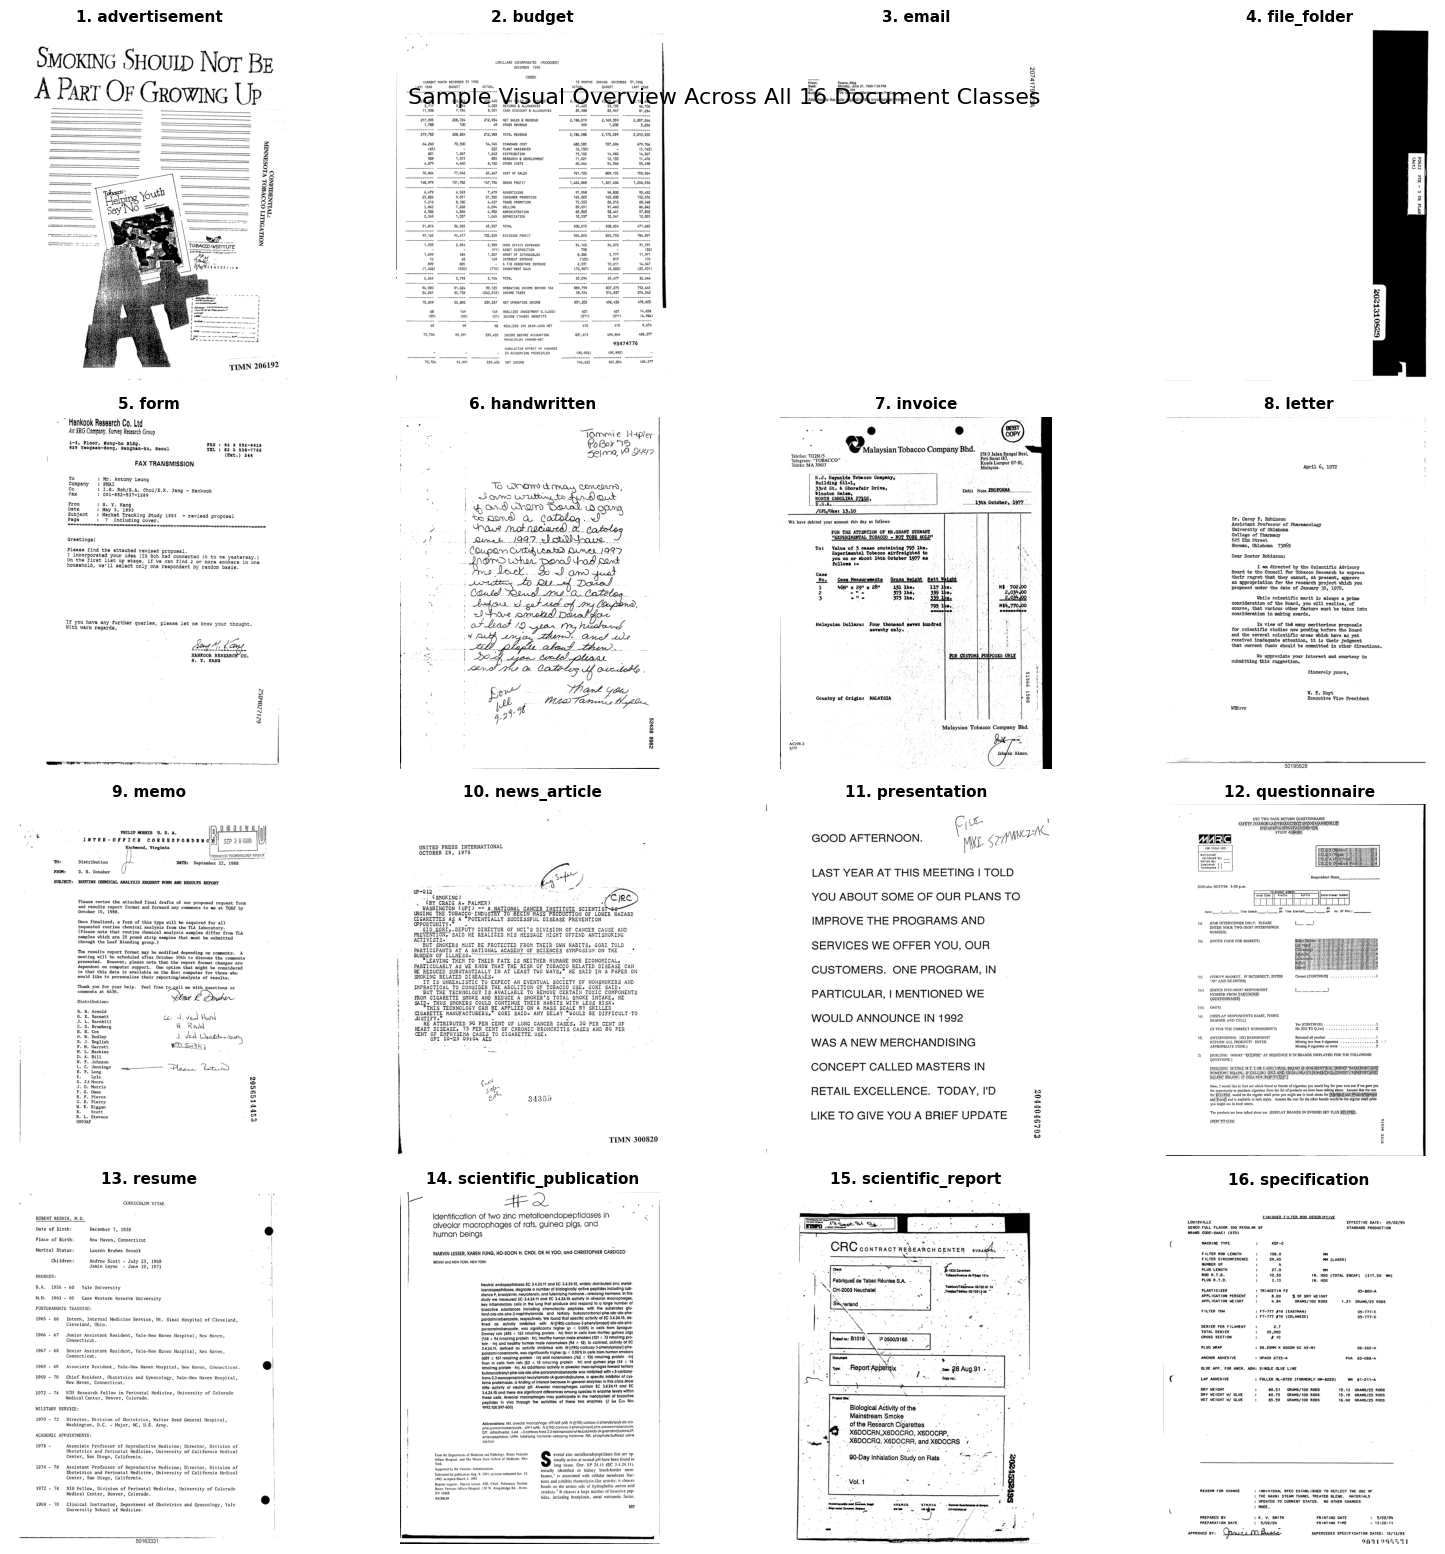

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path to the training directory containing all 16 category folders
train_dir = "document_dataset/rvl-cdip-small-200/train"
categories = sorted(os.listdir(train_dir))

# Create a 4x4 subplot grid to display one sample from each class
plt.figure(figsize=(16, 16))

for idx, category in enumerate(categories):
    category_folder = os.path.join(train_dir, category)

    # Grab the first available image in this folder
    image_files = os.listdir(category_folder)
    sample_img_path = os.path.join(category_folder, image_files[0])

    # Load and display the image
    img = Image.open(sample_img_path)

    plt.subplot(4, 4, idx + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{idx + 1}. {category}", fontsize=11, fontweight="bold")
    plt.axis("off")

plt.suptitle("Sample Visual Overview Across All 16 Document Classes", fontsize=16, y=0.92)
plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image
from tqdm import tqdm

base_dataset_dir = "document_dataset/rvl-cdip-small-200"

# Step 1: Collect all .tif files across train and val splits
tif_files_to_convert = []
for root, dirs, files in os.walk(base_dataset_dir):
    for file in files:
        if file.lower().endswith(".tif") or file.lower().endswith(".tiff"):
            tif_files_to_convert.append(os.path.join(root, file))

print(f"Total TIFF images found: {len(tif_files_to_convert)}")
print("Starting conversion to JPEG format...\n")

# Step 2: Convert each image to RGB JPEG and remove original .tif
converted_count = 0
for file_path in tqdm(tif_files_to_convert, desc="Converting documents"):
    try:
        with Image.open(file_path) as img:
            # ResNet-50 requires 3-channel RGB
            rgb_image = img.convert("RGB")
            new_jpg_path = os.path.splitext(file_path)[0] + ".jpg"
            rgb_image.save(new_jpg_path, format="JPEG", quality=95)

        # Remove the old .tif file
        os.remove(file_path)
        converted_count += 1
    except Exception as err:
        print(f"Failed to convert {file_path}: {err}")

print(f"\nSuccessfully converted {converted_count} files to .jpg format.")

Total TIFF images found: 3200
Starting conversion to JPEG format...



Converting documents: 100%|██████████| 3200/3200 [00:28<00:00, 111.51it/s]


Successfully converted 3200 files to .jpg format.


In [ ]:
import tensorflow as tf

# Standard input image dimensions required by ResNet-50
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Paths to the converted dataset
train_dir = "document_dataset/rvl-cdip-small-200/train"
val_dir = "document_dataset/rvl-cdip-small-200/val"

print("Building training dataset pipeline...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

print("\nBuilding validation dataset pipeline...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Extract and display the class names discovered by TensorFlow
class_names = train_ds.class_names
print(f"\nTensorFlow successfully identified {len(class_names)} classes:")
print(class_names)

Building training dataset pipeline...
Found 2560 files belonging to 16 classes.

Building validation dataset pipeline...
Found 640 files belonging to 16 classes.

TensorFlow successfully identified 16 classes:
['advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']


In [ ]:
import numpy as np

print("Extracting one batch of images from the pipeline...\n")

# .take(1) grabs exactly one batch (32 images) from our dataset
for image_batch, label_batch in train_ds.take(1):

    # We select the very first image in this batch (Index 0)
    first_image = image_batch[0]

    print("--- TENSOR PROPERTIES ---")
    print(f"Image Tensor Shape: {first_image.shape}")
    # Expected output: (224, 224, 3) -> Height, Width, RGB Color Channels
    print(f"Data Type: {first_image.dtype}")

    # Convert the TensorFlow Tensor into a standard NumPy array to view the numbers
    image_matrix = first_image.numpy()

    print(f"\nLowest pixel value (0 = black): {np.min(image_matrix)}")
    print(f"Highest pixel value (255 = white): {np.max(image_matrix)}")

    print("\n--- RAW NUMERICAL MATRIX (Top-Left 5x5 Pixels, Red Channel) ---")
    # We slice a tiny 5x5 grid from the top-left corner of the 1st color channel
    print(image_matrix[0:5, 0:5, 0])

Extracting one batch of images from the pipeline...

--- TENSOR PROPERTIES ---
Image Tensor Shape: (224, 224, 3)
Data Type: <dtype: 'float32'>

Lowest pixel value (0 = black): 0.0
Highest pixel value (255 = white): 255.0

--- RAW NUMERICAL MATRIX (Top-Left 5x5 Pixels, Red Channel) ---
[[255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]]


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import ResNet50
import tensorflow as tf

In [ ]:
# 1. Optimize the data pipeline so the GPU doesn't wait for images to load
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Downloading ResNet-50 Base Model...")

In [ ]:
# 2. Load the pre-trained ResNet-50 model
# include_top=False means we chop off its original ImageNet classifier head
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# 3. Freeze the base model so we don't destroy its pre-trained visual knowledge
base_model.trainable = False

In [ ]:
# 4. Build our custom classification network on top of ResNet-50
print("Building custom classification layers...")
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),         # Condenses the complex feature maps into a single vector
    layers.Dense(256, activation='relu'),    # A hidden processing layer to learn document patterns
    layers.Dropout(0.3),                     # Randomly drops 30% of connections to prevent memorization
    layers.Dense(16, activation='softmax')   # Final output layer for our 16 document classes
])

Building custom classification layers...


In [ ]:
# 5. Compile the model (giving it a learning rate and a way to measure its mistakes)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("\nModel Architecture Blueprint:")
model.summary()


Model Architecture Blueprint:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,368 (92.00 MB)

 Trainable params: 528,656 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

print("Initializing Model Training...\n")

# Create a checkpoint to automatically save the best version of the model
checkpoint = ModelCheckpoint(
    filepath="document_classifier_model.keras",
    monitor="val_accuracy", # We care most about how it performs on the unseen validation data
    save_best_only=True,    # Only save if the model improves
    mode="max",
    verbose=1
)

# Train the model for 10 Epochs (10 full passes through the 2,560 images)
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

print("\nTraining Complete! The smartest version of your model has been saved.")

Initializing Model Training...

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2250 - loss: 2.6360
Epoch 1: val_accuracy improved from None to 0.37187, saving model to document_classifier_model.keras

Epoch 1: finished saving model to document_classifier_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 316ms/step - accuracy: 0.2953 - loss: 2.3279 - val_accuracy: 0.3719 - val_loss: 2.0247
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3986 - loss: 1.8990
Epoch 2: val_accuracy improved from 0.37187 to 0.40625, saving model to document_classifier_model.keras

Epoch 2: finished saving model to document_classifier_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.4160 - loss: 1.8678 - val_accuracy: 0.4062 - val_loss: 1.9071
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4396 - loss: 1.7386
Epoch 3: val_accuracy improved from 0.40625 to 0.42969, saving model to document_classifier_model.keras

Epoch 3: finished saving model to

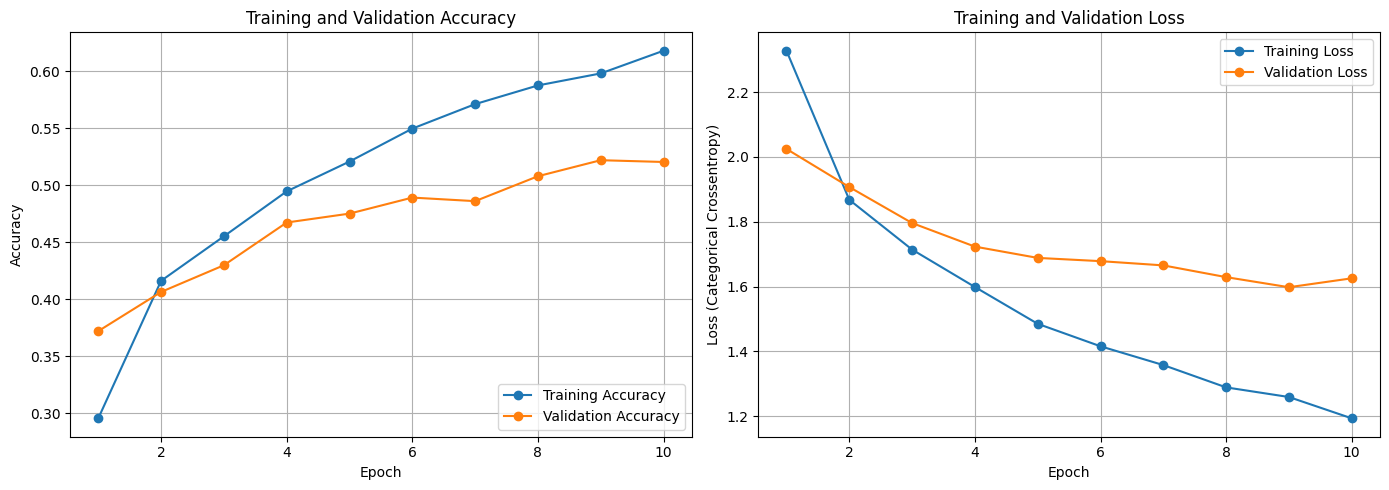

In [ ]:
import matplotlib.pyplot as plt

# Extract the metrics from the 'history' dictionary we saved during training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

# Create a side-by-side plot
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.grid(True)

plt.tight_layout()
plt.show()

Building Data Augmentation Pipeline...


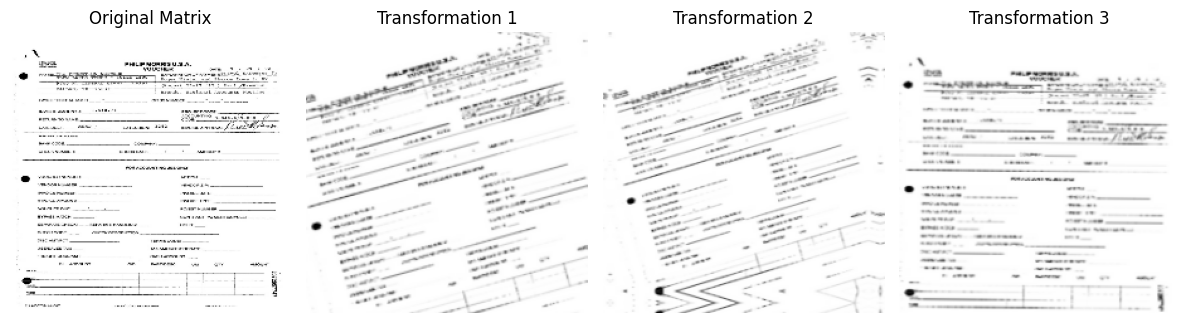

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

print("Building Data Augmentation Pipeline...")

# Create a sequence of geometric matrix transformations
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05), # Randomly rotate documents by up to ~18 degrees
    layers.RandomZoom(0.1),      # Randomly zoom in or out by 10%
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05) # Shift the image slightly
])

# Let's visualize what the augmentation is actually doing to a single matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Grab one batch of images
for image_batch, _ in train_ds.take(1):
    first_image = image_batch[0]

    # Show Original
    plt.subplot(1, 4, 1)
    plt.imshow(first_image.numpy().astype("uint8"))
    plt.title("Original Matrix")
    plt.axis("off")

    # Show 3 augmented variations
    for i in range(2, 5):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.subplot(1, 4, i)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Transformation {i-1}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

print("Building Model V2 with Data Augmentation...")

Building Model V2 with Data Augmentation...


In [ ]:
# We build a new sequential model, starting with the augmentation layers
model_v2 = models.Sequential([
    data_augmentation,                       # 1. Alter the image matrix
    base_model,                              # 2. Pass to frozen ResNet-50
    layers.GlobalAveragePooling2D(),         # 3. Condense the features
    layers.Dense(256, activation='relu'),    # 4. Hidden processing layer
    layers.Dropout(0.4),                     # 5. Slightly higher dropout (40%) for better regularization
    layers.Dense(16, activation='softmax')   # 6. Final 16 document classes
])

In [ ]:
# Compile the new model
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Set up a new checkpoint so we don't overwrite our V1 model
checkpoint_v2 = ModelCheckpoint(
    filepath="document_classifier_model_v2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
# Train the augmented model
print("\nInitiating Training for Model V2 (15 Epochs)...")
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint_v2]
)

print("\nModel V2 Training Complete!")


Initiating Training for Model V2 (15 Epochs)...
Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1874 - loss: 2.6941
Epoch 1: val_accuracy improved from None to 0.19375, saving model to document_classifier_model_v2.keras

Epoch 1: finished saving model to document_classifier_model_v2.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.2621 - loss: 2.4066 - val_accuracy: 0.1937 - val_loss: 2.3973
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3586 - loss: 2.0507
Epoch 2: val_accuracy improved from 0.19375 to 0.26094, saving model to document_classifier_model_v2.keras

Epoch 2: finished saving model to document_classifier_model_v2.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.3871 - loss: 2.0070 - val_accuracy: 0.2609 - val_loss: 2.2606
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4153 - loss: 1.8865
Epoch 3: val_accuracy did not improve from 0.26094
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0

In [ ]:
from tensorflow.keras.optimizers import Adam

print("Initiating Fine-Tuning Phase...")

Initiating Fine-Tuning Phase...


In [ ]:
# 1. Unfreeze the entire ResNet-50 base model
base_model.trainable = True

In [ ]:
# 2. We don't want to change the very first layers (which detect basic lines and curves).
# Let's freeze the first 100 layers and only let the deeper, complex layers learn the documents.
print(f"ResNet-50 total layers: {len(base_model.layers)}")
for layer in base_model.layers[:100]:
    layer.trainable = False

ResNet-50 total layers: 175


In [ ]:
# 3. Re-compile the model.
# CRITICAL: We MUST use a very small learning rate (1e-5) for fine-tuning.
# A normal learning rate would mathematically shatter the pre-trained weights.
model_v2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 4. Set up a new checkpoint for the fine-tuned version
checkpoint_finetuned = ModelCheckpoint(
    filepath="document_classifier_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
print("\nStarting Fine-Tuning Training (10 Epochs)...")
# We continue training the ALREADY trained model_v2, but now the base is unfrozen
history_finetune = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_finetuned]
)

print("\nFine-Tuning Complete! The model's core features have been adapted for documents.")


Starting Fine-Tuning Training (10 Epochs)...
Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.1668 - loss: 4.1116
Epoch 1: val_accuracy improved from None to 0.33437, saving model to document_classifier_finetuned.keras

Epoch 1: finished saving model to document_classifier_finetuned.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 332ms/step - accuracy: 0.2035 - loss: 3.4733 - val_accuracy: 0.3344 - val_loss: 2.1786
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.3283 - loss: 2.3847
Epoch 2: val_accuracy improved from 0.33437 to 0.37656, saving model to document_classifier_finetuned.keras

Epoch 2: finished saving model to document_classifier_finetuned.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 308ms/step - accuracy: 0.3680 - loss: 2.1640 - val_accuracy: 0.3766 - val_loss: 2.1545
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4240 - loss: 1.8923
Epoch 3: val_accuracy improved from 0.37656 to 0.37813, saving model to document_classifier_finetuned.ker

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load the smartest, most robust version of our model from the hard drive
print("Loading Fine-Tuned Model for Testing...")
best_model = tf.keras.models.load_model("document_classifier_finetuned.keras")

# 2. Grab exactly one batch of unseen validation images
for image_batch, label_batch in val_ds.take(1):

    # Let's pick the 5th image in the batch (Index 4)
    test_image = image_batch[4]
    true_label_matrix = label_batch[4]

    # 3. Find out what the actual document is (True Answer)
    true_class_index = np.argmax(true_label_matrix.numpy())
    true_class_name = class_names[true_class_index]

    # 4. Ask the model to predict the document type
    # We have to expand dimensions because the model expects a batch, even if it's a batch of 1
    image_for_model = tf.expand_dims(test_image, 0)
    prediction_scores = best_model.predict(image_for_model)

    # 5. Extract the highest probability prediction
    predicted_class_index = np.argmax(prediction_scores[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(prediction_scores[0]) * 100

    # 6. Display the image and the model's prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.numpy().astype("uint8"))

    # Color the title green if it's correct, red if it's wrong
    title_color = 'green' if true_class_name == predicted_class_name else 'red'
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.1f}%)\nActual: {true_class_name}",
              color=title_color, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.show()

    # Show the full probability distribution just to see its mathematical "thought process"
    print("\n--- Model's Confidence Across All 16 Classes ---")
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<25}: {prediction_scores[0][i]*100:.2f}%")

Loading Fine-Tuned Model for Testing...


ValueError: File not found: filepath=document_classifier_finetuned.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

print("--- EXPERIMENT 1 (UPGRADED): High Epochs + Safety Nets ---")

--- EXPERIMENT 1 (UPGRADED): High Epochs + Safety Nets ---


In [ ]:
# 1. The Dynamic Learning Rate (Shifts gears when stuck)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
# 2. Early Stopping (The Emergency Brake)
# If validation loss doesn't improve for 5 epochs in a row, kill the training.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True, # Automatically reverts to the smartest version
    verbose=1
)

In [ ]:
# 3. The Save Checkpoint
checkpoint_exp1 = ModelCheckpoint(
    filepath="document_classifier_exp1_high_epochs.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=0 # Turning off verbose so the screen doesn't clutter
)

In [ ]:
# 4. Train with high epochs, trusting our safety nets to stop it when ready
MAX_EPOCHS = 30

print(f"\nStarting Training for up to {MAX_EPOCHS} Epochs...")
history_exp1 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=[checkpoint_exp1, lr_scheduler, early_stopping]
)

print("\nExperiment 1 Complete!")


Starting Training for up to 30 Epochs...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 364ms/step - accuracy: 0.6625 - loss: 1.0360 - val_accuracy: 0.4328 - val_loss: 2.1093 - learning_rate: 1.0000e-05
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 313ms/step - accuracy: 0.6785 - loss: 1.0025 - val_accuracy: 0.4406 - val_loss: 2.0744 - learning_rate: 1.0000e-05
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 300ms/step - accuracy: 0.6867 - loss: 0.9581 - val_accuracy: 0.4500 - val_loss: 2.0758 - learning_rate: 1.0000e-05
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.6923 - loss: 0.9503
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 281ms/step - accuracy: 0.7051 - loss: 0.9138 - val_accuracy: 0.4281 - val_loss: 2.1501 - learning_rate: 1.0000e-05
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 284ms/step - accuracy: 0.7203 - loss: 0.8556 - val_accuracy: 0.4344 - val_loss: 2.1047 - learning_rate: 2.0000e-06
Epoch 6/30
80/80 ━━━━

In [ ]:
print("--- EXPERIMENT 2: Unfreezing Deeper Layers ---")

# 1. Unfreeze down to layer 50 instead of 100
base_model.trainable = True
for layer in base_model.layers[:50]:
    layer.trainable = False

--- EXPERIMENT 2: Unfreezing Deeper Layers ---


In [ ]:
# 2. Recompile with our micro learning rate
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 3. New Checkpoint so we don't overwrite Exp 1
checkpoint_exp2 = ModelCheckpoint(
    filepath="document_classifier_exp2_deep_unfreeze.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=0
)

In [ ]:
print(f"ResNet-50 total layers: {len(base_model.layers)}")
print(f"Trainable layers now starting from layer 51...")
print("\nStarting Training for Experiment 2...")

ResNet-50 total layers: 175
Trainable layers now starting from layer 51...

Starting Training for Experiment 2...


In [ ]:
# 4. Train the deeper model using the same safety nets
history_exp2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=[checkpoint_exp2, lr_scheduler, early_stopping]
)

print("\nExperiment 2 Complete!")

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 51s 420ms/step - accuracy: 0.7199 - loss: 0.8486 - val_accuracy: 0.4563 - val_loss: 2.0546 - learning_rate: 1.0000e-05
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.7387 - loss: 0.7990 - val_accuracy: 0.4578 - val_loss: 2.1597 - learning_rate: 1.0000e-05
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7625 - loss: 0.7392
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step - accuracy: 0.7570 - loss: 0.7440 - val_accuracy: 0.4406 - val_loss: 2.1500 - learning_rate: 1.0000e-05
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 283ms/step - accuracy: 0.7711 - loss: 0.7186 - val_accuracy: 0.4453 - val_loss: 2.1559 - learning_rate: 2.0000e-06
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.7806 - loss: 0.7269
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 282ms/step - accuracy: 0.77

In [ ]:
import tensorflow as tf

print("--- REBUILDING PIPELINE TO PREVENT MEMORY CRASH ---")

HIGH_RES = 336
# FIX 1: Cut the batch size in half so the GPU doesn't choke
SAFE_BATCH_SIZE = 16

--- REBUILDING PIPELINE TO PREVENT MEMORY CRASH ---


In [ ]:
print("Building Training Dataset...")
train_ds_high = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(HIGH_RES, HIGH_RES),
    batch_size=SAFE_BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

Building Training Dataset...
Found 2560 files belonging to 16 classes.


In [ ]:
print("\nBuilding Validation Dataset...")
val_ds_high = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(HIGH_RES, HIGH_RES),
    batch_size=SAFE_BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Building Validation Dataset...
Found 640 files belonging to 16 classes.


In [ ]:
# FIX 2: We use .prefetch() for speed, but we completely REMOVE .cache()
train_ds_high = train_ds_high.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_high = val_ds_high.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nSafe High-Resolution Pipelines Ready!")


Safe High-Resolution Pipelines Ready!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow as tf

In [ ]:
print("--- Defining Safety Nets ---")
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

--- Defining Safety Nets ---


In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/Document_AI_Models"

os.makedirs(MODEL_DIR, exist_ok=True)

print("✅ Model folder ready:")
print(MODEL_DIR)

✅ Model folder ready:
/content/drive/MyDrive/Document_AI_Models


In [ ]:
print("--- Building Model V3 (High-Resolution) ---")

--- Building Model V3 (High-Resolution) ---


In [ ]:
# 1. Download a fresh ResNet-50 blueprint configured for the new matrix size
base_model_high_res = tf.keras.applications.resnet50.ResNet50(
    input_shape=(HIGH_RES, HIGH_RES, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# 2. Apply our successful Layer 50 unfreeze strategy immediately
base_model_high_res.trainable = True
for layer in base_model_high_res.layers[:50]:
    layer.trainable = False

In [ ]:
# 3. Create a FRESH augmentation pipeline
data_augmentation_high_res = tf.keras.models.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05)
])

In [ ]:
# 4. Assemble the V3 Architecture
model_v3 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(HIGH_RES, HIGH_RES, 3)),
    data_augmentation_high_res,
    base_model_high_res,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(16, activation='softmax')
])

In [ ]:
# 5. Compile with the micro learning rate
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================================================
# SAVE BEST MODEL TO GOOGLE DRIVE
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "document_classifier_v3_high_res.keras"
)

checkpoint_v3 = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


# ============================================================
# SAVE FINAL MODEL PATH
# ============================================================

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "document_classifier_v3_final.keras"
)


# ============================================================
# LEARNING RATE + EARLY STOPPING
# ============================================================

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# ============================================================
# TRAIN MODEL V3
# ============================================================

print("\n🚀 Starting Training for Model V3...")
print("Best model will be saved to:")
print(BEST_MODEL_PATH)

history_v3 = model_v3.fit(
    train_ds_high,
    validation_data=val_ds_high,
    epochs=30,
    callbacks=[
        checkpoint_v3,
        lr_scheduler,
        early_stopping
    ]
)


# ============================================================
# SAVE FINAL MODEL
# ============================================================

print("\n💾 Saving final model to Google Drive...")

model_v3.save(FINAL_MODEL_PATH)

print("✅ FINAL MODEL SAVED!")
print(FINAL_MODEL_PATH)


# ============================================================
# VERIFY BOTH MODELS
# ============================================================

print("\n=== VERIFYING GOOGLE DRIVE ===")

for path in [BEST_MODEL_PATH, FINAL_MODEL_PATH]:

    if os.path.exists(path):

        size_mb = os.path.getsize(path) / (1024 * 1024)

        print(f"✅ {os.path.basename(path)}")
        print(f"   Size: {size_mb:.2f} MB")

    else:

        print(f"❌ NOT FOUND: {path}")


🚀 Starting Training for Model V3...
Best model will be saved to:
/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras
Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.1160 - loss: 2.8413
Epoch 1: val_accuracy improved from None to 0.20312, saving model to /content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 91s 476ms/step - accuracy: 0.1816 - loss: 2.6347 - val_accuracy: 0.2031 - val_loss: 2.5303 - learning_rate: 1.0000e-05
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.3203 - loss: 2.2037
Epoch 2: val_accuracy improved from 0.20312 to 0.34844, saving model to /content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"

if os.path.exists(model_path):
    print("✅ V3 MODEL FOUND!")
    print(f"Size: {os.path.getsize(model_path) / (1024**2):.2f} MB")
else:
    print("❌ V3 model not found.")

❌ V3 model not found.


In [ ]:
import os

drive_root = "/content/drive/MyDrive"

print("🔍 Searching entire Google Drive for V3 model...\n")

found = []

for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".keras"):
            found.append(os.path.join(root, file))

if found:
    print("✅ Found .keras files:\n")
    for path in found:
        size = os.path.getsize(path) / (1024 * 1024)
        print(f"{size:.2f} MB  →  {path}")
else:
    print("❌ No .keras files found anywhere in Google Drive.")

🔍 Searching entire Google Drive for V3 model...

❌ No .keras files found anywhere in Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/Document_AI_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

test_file = os.path.join(MODEL_DIR, "test.txt")

with open(test_file, "w") as f:
    f.write("Google Drive write test successful")

print("✅ Test file created:")
print(test_file)
print("Exists:", os.path.exists(test_file))

✅ Test file created:
/content/drive/MyDrive/Document_AI_Models/test.txt
Exists: True


In [ ]:
import os

folder = "/content/drive/MyDrive/Document_AI_Models"

print("Folder exists:", os.path.exists(folder))

if os.path.exists(folder):
    print("\nFiles inside Document_AI_Models:")
    for file in os.listdir(folder):
        print(" -", file)
else:
    print("❌ Document_AI_Models folder does not exist")

Folder exists: True

Files inside Document_AI_Models:
 - test.txt


In [ ]:
import os

model_path = "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("✅ V3 MODEL IS SAFELY STORED IN GOOGLE DRIVE")
    print(f"File size: {os.path.getsize(model_path)/(1024**2):.2f} MB")

Exists: False


In [ ]:
import os

model_path = "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("✅ V3 MODEL IS SAFELY STORED IN GOOGLE DRIVE")
    print(f"File size: {os.path.getsize(model_path)/(1024**2):.2f} MB")

Exists: False


In [ ]:
import os

print("=== CHECKING DRIVE FOLDER ===")

drive_folder = "/content/drive/MyDrive/Document_AI_Models"

print("Folder exists:", os.path.exists(drive_folder))

if os.path.exists(drive_folder):
    print("Files:")
    for root, dirs, files in os.walk(drive_folder):
        for file in files:
            print(os.path.join(root, file))


print("\n=== CHECKING /content ===")

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".keras"):
            matches.append(os.path.join(root, file))

if matches:
    print("Found .keras files:")
    for f in matches:
        print(f)
else:
    print("❌ No .keras files found in /content")

=== CHECKING DRIVE FOLDER ===
Folder exists: True
Files:
/content/drive/MyDrive/Document_AI_Models/test.txt

=== CHECKING /content ===
❌ No .keras files found in /content


In [ ]:
import tensorflow as tf
import os

test_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

test_path = "/content/drive/MyDrive/Document_AI_Models/save_test.keras"

print("Saving test model...")
test_model.save(test_path)

print("\nChecking file...")
print("Exists:", os.path.exists(test_path))

if os.path.exists(test_path):
    print("✅ GOOGLE DRIVE KERAS SAVING WORKS!")
    print(f"File size: {os.path.getsize(test_path)/(1024**2):.2f} MB")
else:
    print("❌ GOOGLE DRIVE KERAS SAVING DOES NOT WORK")

Saving test model...

Checking file...
Exists: True
✅ GOOGLE DRIVE KERAS SAVING WORKS!
File size: 0.01 MB


In [ ]:
import os

test_path = "/content/drive/MyDrive/Document_AI_Models/save_test.keras"

if os.path.exists(test_path):
    os.remove(test_path)
    print("✅ Test file removed")

✅ Test file removed


In [ ]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

print("Model built:", model_v3.built)
print("Model compiled:", model_v3.optimizer is not None)

print("Train dataset:", train_ds_high)
print("Validation dataset:", val_ds_high)

TensorFlow: 2.20.0
Keras: 3.13.2
Model built: True
Model compiled: True
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 336, 336, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 16), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 336, 336, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 16), dtype=tf.float32, name=None))>


In [ ]:
# ============================================================
# CLEANLY RECOMPILE MODEL V3
# ============================================================

print("🔄 Recompiling Model V3...")

# Make sure the fine-tuning configuration is correct
base_model_high_res.trainable = True

for layer in base_model_high_res.layers[:50]:
    layer.trainable = False

# Recompile from a fresh optimizer
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model V3 recompiled successfully")
print("Trainable parameters:",
      sum(tf.keras.backend.count_params(w) for w in model_v3.trainable_weights))

🔄 Recompiling Model V3...
✅ Model V3 recompiled successfully
Trainable parameters: 23455760


In [ ]:
# ============================================================
# QUICK 1-BATCH TEST
# ============================================================

print("🧪 Testing one training batch...")

for images, labels in train_ds_high.take(1):

    print("Images:", images.shape)
    print("Labels:", labels.shape)

    result = model_v3.train_on_batch(
        images,
        labels
    )

    print("✅ One training batch worked!")
    print("Loss:", result[0])
    print("Accuracy:", result[1])

🧪 Testing one training batch...
Images: (16, 336, 336, 3)
Labels: (16, 16)
✅ One training batch worked!
Loss: 3.0431123
Accuracy: 0.0625


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"

print("Checking model...")

if os.path.exists(MODEL_PATH):
    print("✅ Model found!")
    print(f"Size: {os.path.getsize(MODEL_PATH) / (1024*1024):.2f} MB")
else:
    print("❌ Model not found!")

print("\nLoading model...")

model_v3 = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

Checking model...
✅ Model found!
Size: 271.70 MB

Loading model...
✅ Model loaded successfully!


In [ ]:
import tensorflow as tf

HIGH_RES = 336
BATCH_SIZE = 16

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
import os

# Check possible dataset locations

possible_paths = [
    "/content/document_dataset/rvl-cdip-small-200",
    "/content/drive/MyDrive/document_dataset/rvl-cdip-small-200",
]

for path in possible_paths:
    print("\nChecking:", path)
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        print("Contents:", os.listdir(path))


Checking: /content/document_dataset/rvl-cdip-small-200
Exists: False

Checking: /content/drive/MyDrive/document_dataset/rvl-cdip-small-200
Exists: False


In [ ]:
import os

print("🔍 Searching Google Drive for possible dataset folders...\n")

keywords = [
    "document",
    "rvl",
    "cdip",
    "dataset",
    "train",
    "val",
    "test"
]

drive_root = "/content/drive/MyDrive"

matches = []

for root, dirs, files in os.walk(drive_root):
    folder_name = os.path.basename(root).lower()

    if any(keyword in folder_name for keyword in keywords):
        matches.append(root)

print("Possible folders found:\n")

for folder in matches[:100]:
    print(folder)

print(f"\nTotal matches: {len(matches)}")

🔍 Searching Google Drive for possible dataset folders...

Possible folders found:

/content/drive/MyDrive/Document_AI_Models

Total matches: 1


In [ ]:
# Check whether your model's class names / dataset information
# are still available in the current runtime

variables_to_check = [
    "class_names",
    "train_ds_high",
    "val_ds_high",
    "test_ds_high",
    "HIGH_RES"
]

for var in variables_to_check:
    if var in globals():
        print(f"✅ {var} exists")
        try:
            print(globals()[var])
        except:
            pass
    else:
        print(f"❌ {var} does not exist")

❌ class_names does not exist
❌ train_ds_high does not exist
❌ val_ds_high does not exist
❌ test_ds_high does not exist
✅ HIGH_RES exists
336


In [ ]:
print("Model input shape:", model_v3.input_shape)
print("Model output shape:", model_v3.output_shape)

Model input shape: (None, 336, 336, 3)
Model output shape: (None, 16)


In [ ]:
print("Model loaded:", model_v3 is not None)

print("\nLooking for class information:")
print("Classes from model output:", model_v3.output_shape[-1])

Model loaded: True

Looking for class information:
Classes from model output: 16


In [ ]:
import os

print("Searching current Colab and Google Drive for notebooks, Python files, and class information...")

search_locations = [
    "/content",
    "/content/drive/MyDrive"
]

keywords = [
    "class_names",
    "labels",
    "letter",
    "form",
    "invoice",
    "resume"
]

for root_location in search_locations:
    print(f"\n📂 Searching: {root_location}")

    for root, dirs, files in os.walk(root_location):
        for file in files:
            if file.endswith((".ipynb", ".py", ".txt")):
                path = os.path.join(root, file)

                try:
                    with open(path, "r", encoding="utf-8", errors="ignore") as f:
                        content = f.read().lower()

                    if any(keyword in content for keyword in keywords):
                        print("Found possible file:", path)

                except:
                    pass

Searching current Colab and Google Drive for notebooks, Python files, and class information...

📂 Searching: /content
Found possible file: /content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb

📂 Searching: /content/drive/MyDrive
Found possible file: /content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb


In [ ]:
import json

NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    notebook = json.load(f)

print("🔍 Searching notebook for class_names and dataset code...\n")

for i, cell in enumerate(notebook["cells"]):

    if cell["cell_type"] == "code":

        source = "".join(cell["source"])

        if any(keyword in source for keyword in [
            "class_names",
            "image_dataset_from_directory",
            "train_ds",
            "test_ds"
        ]):

            print(f"\n{'='*70}")
            print(f"📌 CELL {i}")
            print(f"{'='*70}")
            print(source)

🔍 Searching notebook for class_names and dataset code...


📌 CELL 10
import tensorflow as tf

# Standard input image dimensions required by ResNet-50
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Paths to the converted dataset
train_dir = "document_dataset/rvl-cdip-small-200/train"
val_dir = "document_dataset/rvl-cdip-small-200/val"

print("Building training dataset pipeline...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

print("\nBuilding validation dataset pipeline...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Extract and display the class names discovered by TensorFlow
class_names = train_ds.class_names
print(f"\nTensorFlow successfully identified {len(class_names)} classes:")
p

In [ ]:
import json
import re

NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    notebook = json.load(f)

print("🔍 Searching notebook outputs for the 16 document classes...\n")

found = False

for i, cell in enumerate(notebook["cells"]):

    if cell["cell_type"] != "code":
        continue

    source = "".join(cell.get("source", []))

    # Look specifically around class_names
    if "class_names" in source:

        outputs = cell.get("outputs", [])

        for output in outputs:

            text = ""

            if "text" in output:
                text = "".join(output["text"])

            elif "data" in output:
                if "text/plain" in output["data"]:
                    text = "".join(output["data"]["text/plain"])

            if text:
                print(f"📌 CELL {i} OUTPUT:")
                print(text)
                print("-" * 70)

                if "class" in text.lower():
                    found = True

if not found:
    print("⚠️ No class-name output found in the notebook.")

🔍 Searching notebook outputs for the 16 document classes...

📌 CELL 10 OUTPUT:
Building training dataset pipeline...
Found 2560 files belonging to 16 classes.

Building validation dataset pipeline...
Found 640 files belonging to 16 classes.

TensorFlow successfully identified 16 classes:
['advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']

----------------------------------------------------------------------
📌 CELL 33 OUTPUT:
Loading Fine-Tuned Model for Testing...

----------------------------------------------------------------------
📌 CELL 77 OUTPUT:
❌ class_names does not exist
❌ train_ds_high does not exist
❌ val_ds_high does not exist
❌ test_ds_high does not exist
✅ HIGH_RES exists
336

----------------------------------------------------------------------
📌 CELL 80 OUTPUT:
Searching current Colab and Googl

In [ ]:
# ============================================================
# STEP 1A — LOCATE THE RVL-CDIP DATASET
# ============================================================

import os

print("🔍 Searching for RVL-CDIP dataset...\n")

search_roots = [
    "/content",
    "/content/drive/MyDrive"
]

dataset_matches = []

for search_root in search_roots:

    print(f"Searching inside: {search_root}")

    for root, dirs, files in os.walk(search_root):

        # Look specifically for folders named train / val
        # associated with our dataset
        if os.path.basename(root).lower() in ["rvl-cdip-small-200", "train", "val"]:

            path_lower = root.lower()

            if "rvl" in path_lower or "cdip" in path_lower or "document_dataset" in path_lower:

                dataset_matches.append(root)

print("\n" + "="*70)
print("DATASET LOCATIONS FOUND")
print("="*70)

if dataset_matches:

    for path in dataset_matches:
        print("✅", path)

else:

    print("❌ Dataset not found in /content or Google Drive.")

print("\nSearch complete.")

🔍 Searching for RVL-CDIP dataset...

Searching inside: /content
Searching inside: /content/drive/MyDrive

DATASET LOCATIONS FOUND
❌ Dataset not found in /content or Google Drive.

Search complete.


In [ ]:
# ============================================================
# SEARCH GOOGLE DRIVE FOR DATASET ARCHIVES
# ============================================================

import os

print("🔍 Searching Google Drive for dataset archives...\n")

extensions = (
    ".zip",
    ".tar",
    ".tar.gz",
    ".tgz",
    ".rar",
    ".7z"
)

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):

    for file in files:

        if file.lower().endswith(extensions):

            path = os.path.join(root, file)

            name = file.lower()

            # Look for likely dataset-related archives
            if any(keyword in name for keyword in [
                "rvl",
                "cdip",
                "document",
                "dataset"
            ]):

                matches.append(path)

print("=" * 70)
print("POSSIBLE DATASET ARCHIVES")
print("=" * 70)

if matches:

    for path in matches:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {path}")
        print(f"   Size: {size_mb:.2f} MB\n")

else:

    print("❌ No likely dataset archive found.")

print(f"\nTotal matches: {len(matches)}")

🔍 Searching Google Drive for dataset archives...

POSSIBLE DATASET ARCHIVES
❌ No likely dataset archive found.

Total matches: 0


In [ ]:
# ============================================================
# FIND ORIGINAL DATASET PREPARATION CODE
# ============================================================

import json

NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    notebook = json.load(f)

keywords = [
    "download",
    "wget",
    "gdown",
    "kaggle",
    "rvl-cdip",
    "rvl_cdip",
    "rvlcdip",
    "zipfile",
    "extractall",
    "shutil",
    "copyfile",
    "200",
    "document_dataset"
]

print("🔍 Searching notebook for ORIGINAL dataset preparation code...\n")

found_cells = set()

for i, cell in enumerate(notebook["cells"]):

    if cell["cell_type"] != "code":
        continue

    source = "".join(cell.get("source", []))
    source_lower = source.lower()

    if any(keyword.lower() in source_lower for keyword in keywords):

        found_cells.add(i)

        print("=" * 80)
        print(f"📌 CELL {i}")
        print("=" * 80)
        print(source)
        print()

print("=" * 80)
print(f"Total possible dataset-related cells found: {len(found_cells)}")
print("=" * 80)

🔍 Searching notebook for ORIGINAL dataset preparation code...

📌 CELL 0
# 1. Install Kaggle library
!pip install -q kaggle

📌 CELL 1
# 2. Securely input your Kaggle token (paste your KGAT_... token when prompted)
import os
import getpass
print("KGAT_51b023a80af8d470f35e9f7d4c37d782")
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass()

📌 CELL 2
# 3. Download the RVL-CDIP Small dataset from Kaggle
print("Downloading dataset...")
!kaggle datasets download -d vaclavpechtor/rvl-cdip-small-200

📌 CELL 3
# 4. Unzip the dataset quietly (-q)
print("Unzipping dataset...")
!unzip -q rvl-cdip-small-200.zip -d document_dataset

print("Data successfully downloaded and unzipped!")

📌 CELL 4
import os

# Let's check where the dataset was extracted and see the folder names
dataset_path = "document_dataset"

📌 CELL 6
import os

# Exploring inside the extracted folder to see all document categories
base_data_dir = "document_dataset/rvl-cdip-small-200"

print("Scanning document categories and sample count

In [ ]:
!pip install -q kaggle

In [ ]:
import os
import getpass

print("Enter your NEW Kaggle API token below.")
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Kaggle API Token: ")

Enter your NEW Kaggle API token below.
Kaggle API Token: ··········


In [ ]:
# ============================================================
# RESTORE ORIGINAL RVL-CDIP SMALL-200 DATASET
# ============================================================

print("📥 Downloading RVL-CDIP Small-200 dataset...")

!kaggle datasets download -d vaclavpechtor/rvl-cdip-small-200

print("\n✅ Download command completed.")

📥 Downloading RVL-CDIP Small-200 dataset...
Dataset URL: https://www.kaggle.com/datasets/vaclavpechtor/rvl-cdip-small-200
License(s): unknown
100% 294M/294M [00:16<00:00, 18.5MB/s]


✅ Download command completed.


In [ ]:
# ============================================================
# EXTRACT DATASET
# ============================================================

import os

ZIP_PATH = "/content/rvl-cdip-small-200.zip"
EXTRACT_PATH = "/content/document_dataset"

print("📦 Extracting dataset...")

os.makedirs(EXTRACT_PATH, exist_ok=True)

!unzip -q "$ZIP_PATH" -d "$EXTRACT_PATH"

print("✅ Dataset extracted!")

📦 Extracting dataset...
✅ Dataset extracted!


In [ ]:
# ============================================================
# VERIFY RESTORED DATASET
# ============================================================

import os

BASE_DIR = "/content/document_dataset/rvl-cdip-small-200"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

print("\nBase directory:")
print(BASE_DIR)
print("Exists:", os.path.exists(BASE_DIR))

print("\nTrain directory:")
print(TRAIN_DIR)
print("Exists:", os.path.exists(TRAIN_DIR))

print("\nValidation directory:")
print(VAL_DIR)
print("Exists:", os.path.exists(VAL_DIR))


# ------------------------------------------------------------
# CLASS VERIFICATION
# ------------------------------------------------------------

class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("\n" + "=" * 70)
print("CLASSES")
print("=" * 70)

print("Number of classes:", len(class_names))

for i, class_name in enumerate(class_names):
    print(f"{i:2d} → {class_name}")


# ------------------------------------------------------------
# IMAGE COUNTS
# ------------------------------------------------------------

def count_images(directory):

    valid_extensions = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

    total = 0

    for class_name in class_names:

        class_dir = os.path.join(directory, class_name)

        if os.path.exists(class_dir):

            count = sum(
                1
                for f in os.listdir(class_dir)
                if f.lower().endswith(valid_extensions)
            )

            print(f"{class_name:<25} {count:>5}")

            total += count

    return total


print("\n" + "=" * 70)
print("TRAINING SET")
print("=" * 70)

train_count = count_images(TRAIN_DIR)

print("\nTotal training images:", train_count)


print("\n" + "=" * 70)
print("VALIDATION SET")
print("=" * 70)

val_count = count_images(VAL_DIR)

print("\nTotal validation images:", val_count)


print("\n" + "=" * 70)
print("EXPECTED")
print("=" * 70)

print("Expected classes      :", 16)
print("Expected train images :", 2560)
print("Expected val images   :", 640)

if len(class_names) == 16 and train_count == 2560 and val_count == 640:
    print("\n🎉 DATASET VERIFIED SUCCESSFULLY!")
else:
    print("\n⚠️ Dataset does not match the expected structure/counts.")

DATASET VERIFICATION

Base directory:
/content/document_dataset/rvl-cdip-small-200
Exists: True

Train directory:
/content/document_dataset/rvl-cdip-small-200/train
Exists: True

Validation directory:
/content/document_dataset/rvl-cdip-small-200/val
Exists: True

CLASSES
Number of classes: 16
 0 → advertisement
 1 → budget
 2 → email
 3 → file_folder
 4 → form
 5 → handwritten
 6 → invoice
 7 → letter
 8 → memo
 9 → news_article
10 → presentation
11 → questionnaire
12 → resume
13 → scientific_publication
14 → scientific_report
15 → specification

TRAINING SET
advertisement               160
budget                      160
email                       160
file_folder                 160
form                        160
handwritten                 160
invoice                     160
letter                      160
memo                        160
news_article                160
presentation                160
questionnaire               160
resume                      160
scientific_publica

In [ ]:
# ============================================================
# FINAL EVALUATION — BUILD VALIDATION DATASET
# ============================================================

import tensorflow as tf
import numpy as np
import os

HIGH_RES = 336
SAFE_BATCH_SIZE = 16

BASE_DIR = "/content/document_dataset/rvl-cdip-small-200"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

print("🔧 Building final V3 validation pipeline...")

val_ds_high = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(HIGH_RES, HIGH_RES),
    batch_size=SAFE_BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Recover class names from the dataset
class_names = val_ds_high.class_names

# Optimize pipeline without caching the entire dataset
val_ds_high = val_ds_high.prefetch(
    buffer_size=tf.data.AUTOTUNE
)

print("\n" + "=" * 70)
print("VALIDATION DATASET READY")
print("=" * 70)

print("Images      :", 640)
print("Classes     :", len(class_names))
print("Image size  :", f"{HIGH_RES} × {HIGH_RES}")
print("Batch size  :", SAFE_BATCH_SIZE)

print("\nClass order:")

for i, name in enumerate(class_names):
    print(f"{i:2d} → {name}")

🔧 Building final V3 validation pipeline...
Found 0 files belonging to 16 classes.


ValueError: No images found in directory /content/document_dataset/rvl-cdip-small-200/val. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')

In [ ]:
# ============================================================
# RESTORE ORIGINAL IMAGE PREPROCESSING
# TIFF → RGB JPEG
# ============================================================

import os
from PIL import Image
from tqdm import tqdm

BASE_DIR = "/content/document_dataset/rvl-cdip-small-200"

print("🔄 Checking for TIFF images...")

tif_files = []

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            tif_files.append(os.path.join(root, file))

print(f"Found {len(tif_files)} TIFF images.")

if len(tif_files) == 0:
    print("✅ No TIFF images found. Dataset may already be converted.")

else:
    print("\nConverting TIFF → RGB JPEG...\n")

    converted = 0

    for file_path in tqdm(tif_files, desc="Converting"):

        try:
            with Image.open(file_path) as img:

                # Convert to RGB for ResNet50
                rgb_image = img.convert("RGB")

                # Create JPEG path
                jpg_path = os.path.splitext(file_path)[0] + ".jpg"

                # Save JPEG
                rgb_image.save(
                    jpg_path,
                    format="JPEG",
                    quality=95
                )

            # Remove original TIFF
            os.remove(file_path)

            converted += 1

        except Exception as e:
            print(f"❌ Failed: {file_path}")
            print("   Error:", e)

    print(f"\n✅ Successfully converted {converted} images.")

🔄 Checking for TIFF images...
Found 3200 TIFF images.

Converting TIFF → RGB JPEG...



Converting: 100%|██████████| 3200/3200 [00:32<00:00, 97.67it/s]


✅ Successfully converted 3200 images.


In [ ]:
# ============================================================
# VERIFY JPEG DATASET
# ============================================================

import os

TRAIN_DIR = "/content/document_dataset/rvl-cdip-small-200/train"
VAL_DIR = "/content/document_dataset/rvl-cdip-small-200/val"

def count_jpegs(directory):

    total = 0

    for class_name in sorted(os.listdir(directory)):

        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        count = sum(
            1
            for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg"))
        )

        print(f"{class_name:<25} {count}")

        total += count

    return total


print("=" * 70)
print("TRAINING DATA")
print("=" * 70)

train_count = count_jpegs(TRAIN_DIR)

print("\nTotal training JPEGs:", train_count)


print("\n" + "=" * 70)
print("VALIDATION DATA")
print("=" * 70)

val_count = count_jpegs(VAL_DIR)

print("\nTotal validation JPEGs:", val_count)


print("\n" + "=" * 70)
print("EXPECTED")
print("=" * 70)

print("Training    :", train_count, "/ 2560")
print("Validation  :", val_count, "/ 640")

TRAINING DATA
advertisement             160
budget                    160
email                     160
file_folder               160
form                      160
handwritten               160
invoice                   160
letter                    160
memo                      160
news_article              160
presentation              160
questionnaire             160
resume                    160
scientific_publication    160
scientific_report         160
specification             160

Total training JPEGs: 2560

VALIDATION DATA
advertisement             40
budget                    40
email                     40
file_folder               40
form                      40
handwritten               40
invoice                   40
letter                    40
memo                      40
news_article              40
presentation              40
questionnaire             40
resume                    40
scientific_publication    40
scientific_report         40
specification             

In [ ]:
# ============================================================
# FINAL EVALUATION — BUILD VALIDATION DATASET
# ============================================================

import tensorflow as tf
import numpy as np
import os

HIGH_RES = 336
SAFE_BATCH_SIZE = 16

BASE_DIR = "/content/document_dataset/rvl-cdip-small-200"
VAL_DIR = os.path.join(BASE_DIR, "val")

print("🔧 Building final V3 validation pipeline...")

val_ds_high = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(HIGH_RES, HIGH_RES),
    batch_size=SAFE_BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Recover class names
class_names = val_ds_high.class_names

# Optimize pipeline
val_ds_high = val_ds_high.prefetch(
    buffer_size=tf.data.AUTOTUNE
)

print("\n" + "=" * 70)
print("VALIDATION DATASET READY")
print("=" * 70)

print("Images      :", 640)
print("Classes     :", len(class_names))
print("Image size  :", f"{HIGH_RES} × {HIGH_RES}")
print("Batch size  :", SAFE_BATCH_SIZE)

print("\nClass order:")

for i, name in enumerate(class_names):
    print(f"{i:2d} → {name}")

🔧 Building final V3 validation pipeline...
Found 640 files belonging to 16 classes.

VALIDATION DATASET READY
Images      : 640
Classes     : 16
Image size  : 336 × 336
Batch size  : 16

Class order:
 0 → advertisement
 1 → budget
 2 → email
 3 → file_folder
 4 → form
 5 → handwritten
 6 → invoice
 7 → letter
 8 → memo
 9 → news_article
10 → presentation
11 → questionnaire
12 → resume
13 → scientific_publication
14 → scientific_report
15 → specification


In [ ]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"

model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")
print(model.input_shape)
print(model.output_shape)

Model loaded successfully
(None, 336, 336, 3)
(None, 16)


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds_high:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print("Predictions completed:", len(y_pred))

Predictions completed: 640


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy: {accuracy:.2%}\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Validation Accuracy: 60.31%

                        precision    recall  f1-score   support

         advertisement       0.81      0.72      0.76        40
                budget       0.42      0.62      0.51        40
                 email       0.85      0.85      0.85        40
           file_folder       0.78      0.90      0.84        40
                  form       0.54      0.33      0.41        40
           handwritten       0.41      0.90      0.56        40
               invoice       0.56      0.35      0.43        40
                letter       0.55      0.55      0.55        40
                  memo       0.74      0.42      0.54        40
          news_article       0.93      0.33      0.48        40
          presentation       0.57      0.62      0.60        40
         questionnaire       0.78      0.53      0.63        40
                resume       0.76      0.88      0.81        40
scientific_publication       0.51      0.75      0.61        40
     scien

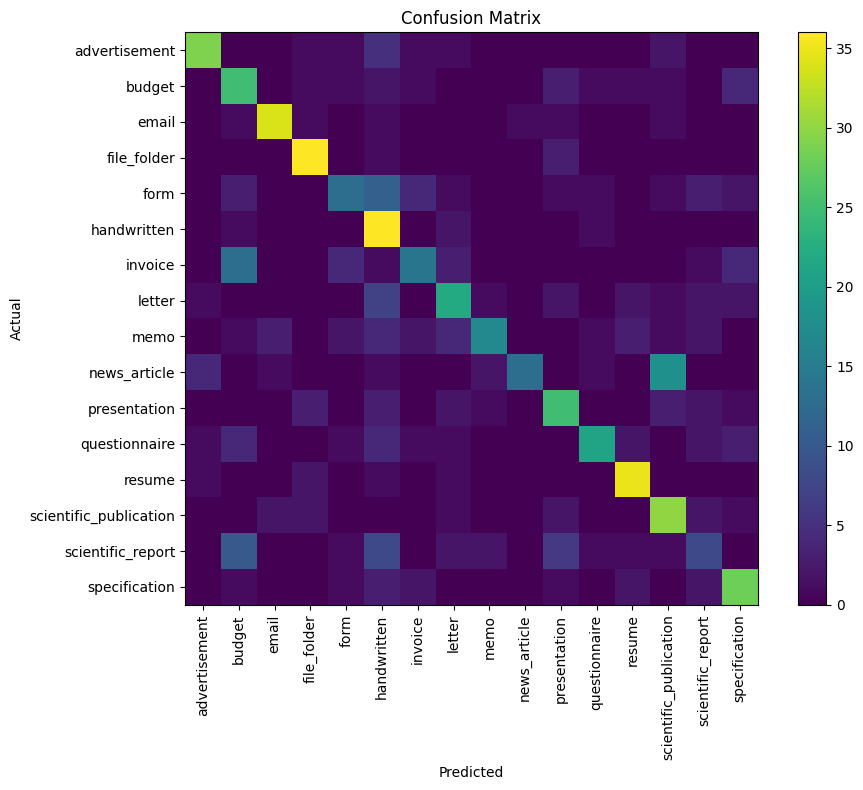

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.xticks(range(16), class_names, rotation=90)
plt.yticks(range(16), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        print(layer.name)
        break

resnet50


In [ ]:
for layer in reversed(model.get_layer("resnet50").layers):
    if len(layer.output.shape) == 4:
        print(layer.name)
        break

conv5_block3_out


In [ ]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

sequential_6 (None, 336, 336, 3)
resnet50 (None, 11, 11, 2048)
global_average_pooling2d_3 (None, 2048)
dense_8 (None, 256)
dropout_3 (None, 256)
dense_9 (None, 16)


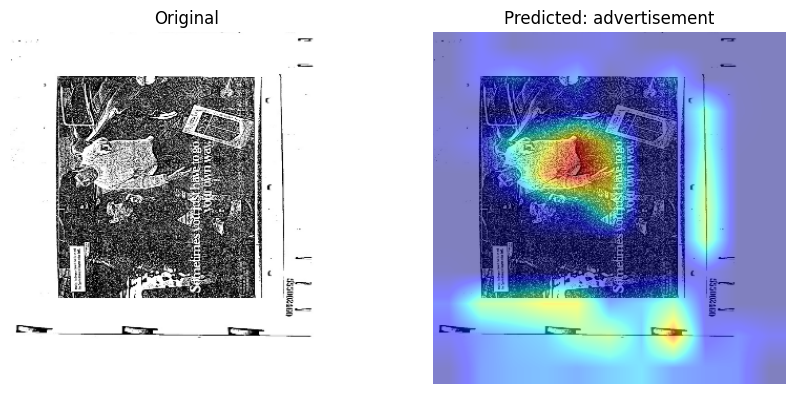

In [ ]:
# Simple Grad-CAM

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

for images, labels in val_ds_high.take(1):
    image = images[0:1]

resnet = model.get_layer("resnet50")
gap = model.get_layer("global_average_pooling2d_3")
dense = model.get_layer("dense_8")
dropout = model.get_layer("dropout_3")
output = model.get_layer("dense_9")

with tf.GradientTape() as tape:
    features = resnet(image, training=False)
    tape.watch(features)

    x = gap(features)
    x = dense(x)
    x = dropout(x, training=False)
    prediction = output(x)

    class_id = tf.argmax(prediction[0])
    loss = prediction[:, class_id]

grads = tape.gradient(loss, features)

weights = tf.reduce_mean(grads, axis=(1, 2))
cam = tf.reduce_sum(features * weights[:, None, None, :], axis=-1)

cam = tf.maximum(cam, 0)
cam = cam / (tf.reduce_max(cam) + 1e-8)

cam = tf.image.resize(cam[..., None], (336, 336))[0, :, :, 0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[0].numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image[0].numpy().astype("uint8"))
plt.imshow(cam.numpy(), cmap="jet", alpha=0.5)
plt.title(f"Predicted: {class_names[class_id.numpy()]}")
plt.axis("off")

plt.show()

In [ ]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 11.8 MB/s eta 0:00:00


In [ ]:
import easyocr

reader = easyocr.Reader(['en'])

print("OCR ready!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR ready!


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import os

invoice_dir = os.path.join(VAL_DIR, "invoice")
invoice_file = os.listdir(invoice_dir)[0]
invoice_path = os.path.join(invoice_dir, invoice_file)

print("Testing:", invoice_file)

result = reader.readtext(invoice_path)

print("\nExtracted text:\n")

for item in result:
    print(item[1])

Testing: ti10161453.jpg

Extracted text:

BIINGSUMMARYSHEE
(one per cllent pur viak)
NAME(S):
JOB #:
TI
CLIEIT T0 BE BILLID:
DTE
PLACE:
Ws_WL
ELsbft
Az
FUTPOSI OF_VISIT:
Asdft
Gx
8
Rk+
~k
DAYS
OR_HouRS Or_Job:
DAY RATZ:
TLD
ERESDS
TLD
ONLY
EPERBES O4LY
EXPENSES
ARLINE
FaRE:
Jyys
ddc
A4Y REFuRD9   (DETAILS) :
BES:
565
C4E REHTAL:
TAIIS:
4L.o 6
PARKINC:
ALS:
Ik.35
OTRS /SPECIn:
TOTAL EXPENSES
550.81
TI1016-1453
@elt
KkG


In [ ]:
text = "\n".join(item[1] for item in result)

print(text)

BIINGSUMMARYSHEE
(one per cllent pur viak)
NAME(S):
JOB #:
TI
CLIEIT T0 BE BILLID:
DTE
PLACE:
Ws_WL
ELsbft
Az
FUTPOSI OF_VISIT:
Asdft
Gx
8
Rk+
~k
DAYS
OR_HouRS Or_Job:
DAY RATZ:
TLD
ERESDS
TLD
ONLY
EPERBES O4LY
EXPENSES
ARLINE
FaRE:
Jyys
ddc
A4Y REFuRD9   (DETAILS) :
BES:
565
C4E REHTAL:
TAIIS:
4L.o 6
PARKINC:
ALS:
Ik.35
OTRS /SPECIn:
TOTAL EXPENSES
550.81
TI1016-1453
@elt
KkG


In [ ]:
import re

match = re.search(r"TI\d{4}[- ]?\d{4}", text)

if match:
    print("Invoice/Job Number:", match.group())
else:
    print("Invoice/Job Number: Not found")

Invoice/Job Number: TI1016-1453


In [ ]:
match = re.search(r"TOTAL EXPENSES\s+(\d+[.,]\d{2})", text, re.IGNORECASE)

if match:
    print("Total Expenses:", match.group(1))
else:
    print("Total Expenses: Not found")

Total Expenses: 550.81


In [ ]:
dates = re.findall(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", text)

print("Dates found:", dates)

Dates found: []


In [ ]:
amounts = re.findall(r"\b\d+\.\d{2}\b", text)

print("Amounts found:", amounts)

Amounts found: ['550.81']


In [ ]:
invoice_match = re.search(r"TI\d{4}[- ]?\d{4}", text)
expense_match = re.search(r"TOTAL EXPENSES\s+(\d+[.,]\d{2})", text, re.IGNORECASE)

data = {
    "invoice_number": invoice_match.group() if invoice_match else None,
    "total_expenses": float(expense_match.group(1)) if expense_match else None
}

print(data)

{'invoice_number': 'TI1016-1453', 'total_expenses': 550.81}


In [ ]:
valid = True

if not data["invoice_number"]:
    valid = False

if data["total_expenses"] is None or data["total_expenses"] < 0:
    valid = False

print("Validation:", "PASSED" if valid else "FAILED")

Validation: PASSED


In [ ]:
import sqlite3

conn = sqlite3.connect("documents.db")

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS documents (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    invoice_number TEXT,
    total_expenses REAL
)
""")

conn.commit()

print("Database ready!")

Database ready!


In [ ]:
cursor.execute(
    "INSERT INTO documents (invoice_number, total_expenses) VALUES (?, ?)",
    (data["invoice_number"], data["total_expenses"])
)

conn.commit()

print("Document saved to database!")

Document saved to database!


In [ ]:
cursor.execute("SELECT * FROM documents")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'TI1016-1453', 550.81)


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 77.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import easyocr
import numpy as np
import re
import sqlite3
from PIL import Image

st.title("Document Intelligence System")

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"
)

reader = easyocr.Reader(["en"])

class_names = [
    "advertisement", "budget", "email", "file_folder",
    "form", "handwritten", "invoice", "letter",
    "memo", "news_article", "presentation", "questionnaire",
    "resume", "scientific_publication", "scientific_report",
    "specification"
]

uploaded_file = st.file_uploader(
    "Upload a document",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Document")

    image_array = np.array(image)
    resized = tf.image.resize(image_array, (336, 336))
    resized = tf.expand_dims(resized, 0)

    prediction = model.predict(resized, verbose=0)
    class_id = np.argmax(prediction[0])
    confidence = prediction[0][class_id] * 100

    st.subheader("Document Classification")
    st.write(f"**Type:** {class_names[class_id]}")
    st.write(f"**Confidence:** {confidence:.2f}%")

    text = reader.readtext(image_array)
    extracted_text = "\n".join(item[1] for item in text)

    st.subheader("Extracted Text")

    if extracted_text:
        st.text(extracted_text)
    else:
        st.write("No text detected.")

    invoice_number = None
    total_expenses = None

    number_match = re.search(
        r"(?:TI\d{4}-\d{4}|INV[-\s]?\d+)",
        extracted_text,
        re.IGNORECASE
    )

    amount_match = re.search(
        r"TOTAL EXPENSES\s*[:\-]?\s*(\d+\.\d{2})",
        extracted_text,
        re.IGNORECASE
    )

    if number_match:
        invoice_number = number_match.group(0)

    if amount_match:
        total_expenses = float(amount_match.group(1))

    st.subheader("Key Information")

    st.write(
        f"**Invoice / Job Number:** "
        f"{invoice_number if invoice_number else 'Not found'}"
    )

    st.write(
        f"**Total Expenses:** "
        f"{total_expenses if total_expenses else 'Not found'}"
    )

    st.subheader("Validation")

    if invoice_number and total_expenses is not None:
        st.success("Validation: PASSED")
    else:
        st.warning("Some information could not be extracted.")

    conn = sqlite3.connect("documents.db")
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS documents (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            invoice_number TEXT,
            total_expenses REAL
        )
    """)

    if invoice_number and total_expenses is not None:
        cursor.execute(
            "INSERT INTO documents (invoice_number, total_expenses) VALUES (?, ?)",
            (invoice_number, total_expenses)
        )
        conn.commit()
        st.success("Document saved to database.")

    conn.close()

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
!cat /content/streamlit.log



2026-08-28 14:53:57.593 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://136.85.12.131:8502



In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output

print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-southeast1-1.prod.colab.dev


In [ ]:
!tail -20 /content/streamlit.log

2026-08-28 14:41:47.373 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-southeast1-1.prod.colab.dev, host=gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p.asia-southeast1-a.c.codatalab-user-runtimes.internal:8007
2026-08-28 14:41:51.057 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-southeast1-1.prod.colab.dev, host=gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p.asia-southeast1-a.c.codatalab-user-runtimes.internal:8007
2026-08-28 14:41:54.311 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-southeast1-1.prod.colab.dev, host=gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p.asia-southeast1-a.c.codatalab-user-runtimes.internal:8007
2026-08-28 14:41:57.522 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-so

In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
!streamlit run app.py --server.address=0.0.0.0 --server.port=8501 --server.enableCORS=false --server.enableXsrfProtection=false &>/content/streamlit.log &

In [ ]:
from google.colab import output
print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-gpu-t4-s-kkb-ass1a1-3ne7tfz5uxj2p-a.asia-southeast1-1.prod.colab.dev


In [ ]:
import os

for root, dirs, files in os.walk("/content/document_dataset"):
    for file in files:
        if "ti1016" in file.lower():
            print(os.path.join(root, file))

/content/document_dataset/rvl-cdip-small-200/train/invoice/ti10161088_1089.jpg
/content/document_dataset/rvl-cdip-small-200/train/invoice/ti10161532.jpg
/content/document_dataset/rvl-cdip-small-200/val/invoice/ti10161453.jpg


In [ ]:
import os

project_files = [
    "/content/app.py",
    "/content/documents.db",
    "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"
]

for file in project_files:
    print("✅" if os.path.exists(file) else "❌", file)

✅ /content/app.py
✅ /content/documents.db
✅ /content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras


In [ ]:
import os

project_dir = "/content/drive/MyDrive/Document_AI_Project"

folders = [
    "model",
    "database",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(project_dir, folder), exist_ok=True)

print("Project folders created.")

Project folders created.


In [ ]:
import shutil

project_dir = "/content/drive/MyDrive/Document_AI_Project"

shutil.copy(
    "/content/app.py",
    project_dir
)

shutil.copy(
    "/content/documents.db",
    os.path.join(project_dir, "database")
)

shutil.copy(
    "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras",
    os.path.join(project_dir, "model")
)

print("Project files copied successfully.")

Project files copied successfully.


In [ ]:
requirements = """tensorflow
streamlit
easyocr
numpy
pillow
"""

with open(
    "/content/drive/MyDrive/Document_AI_Project/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [ ]:
gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/
document_dataset/
"""

with open(
    "/content/drive/MyDrive/Document_AI_Project/.gitignore",
    "w"
) as f:
    f.write(gitignore)

print(".gitignore created.")

.gitignore created.


In [ ]:
import os

project_dir = "/content/drive/MyDrive/Document_AI_Project"

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

    for file in files:
        print("  " * (level + 1) + file)

Document_AI_Project/
  app.py
  requirements.txt
  .gitignore
  model/
    document_classifier_v3_high_res.keras
  database/
    documents.db
  notebooks/


In [1]:
!find . -maxdepth 3 -type f -printf '%p — %s bytes\n' | sort

./.config/active_config — 7 bytes
./.config/config_sentinel — 0 bytes
./.config/configurations/config_default — 94 bytes
./.config/default_configs.db — 12288 bytes
./.config/gce — 5 bytes
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db — 12288 bytes
./.config/.last_opt_in_prompt.yaml — 3 bytes
./.config/.last_survey_prompt.yaml — 37 bytes
./.config/.last_update_check.json — 135 bytes
./sample_data/anscombe.json — 1697 bytes
./sample_data/california_housing_test.csv — 301141 bytes
./sample_data/california_housing_train.csv — 1706430 bytes
./sample_data/mnist_test.csv — 18289443 bytes
./sample_data/mnist_train_small.csv — 36523880 bytes
./sample_data/README.md — 962 bytes


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find /content/drive/MyDrive -maxdepth 5 -type f \
  \( -name "*.keras" -o -name "*.h5" -o -name "*.ipynb" -o -name "*.py" \) \
  -printf '%p — %s bytes\n' | sort

/content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb — 2682865 bytes
/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_final.keras — 284894496 bytes
/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras — 284894496 bytes
/content/drive/MyDrive/Document_AI_Project/app.py — 2981 bytes
/content/drive/MyDrive/Document_AI_Project/model/document_classifier_v3_high_res.keras — 284894496 bytes


In [4]:
!find /content/drive/MyDrive/Document_AI_Project -maxdepth 3 -type f -printf '%p — %s bytes\n' | sort

/content/drive/MyDrive/Document_AI_Project/app.py — 2981 bytes
/content/drive/MyDrive/Document_AI_Project/database/documents.db — 12288 bytes
/content/drive/MyDrive/Document_AI_Project/.gitignore — 57 bytes
/content/drive/MyDrive/Document_AI_Project/model/document_classifier_v3_high_res.keras — 284894496 bytes
/content/drive/MyDrive/Document_AI_Project/requirements.txt — 42 bytes


In [5]:
print(open("/content/drive/MyDrive/Document_AI_Project/app.py").read())


import streamlit as st
import tensorflow as tf
import easyocr
import numpy as np
import re
import sqlite3
from PIL import Image

st.title("Document Intelligence System")

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Document_AI_Models/document_classifier_v3_high_res.keras"
)

reader = easyocr.Reader(["en"])

class_names = [
    "advertisement", "budget", "email", "file_folder",
    "form", "handwritten", "invoice", "letter",
    "memo", "news_article", "presentation", "questionnaire",
    "resume", "scientific_publication", "scientific_report",
    "specification"
]

uploaded_file = st.file_uploader(
    "Upload a document",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Document")

    image_array = np.array(image)
    resized = tf.image.resize(image_array, (336, 336))
    resized = tf.expand_dims(resized, 0)

    prediction = model.predict(resized, verbose=0)
    class

In [6]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Document_AI_Project/app.py",
    "/content/drive/MyDrive/Document_AI_Project/app_backup_working.py"
)

print("✅ Working app backed up!")

✅ Working app backed up!


In [7]:
app_code = r'''
import streamlit as st
import tensorflow as tf
import easyocr
import numpy as np
import re
import sqlite3
from pathlib import Path
from PIL import Image


# ====================================================
# PATHS
# ====================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = BASE_DIR / "model" / "document_classifier_v3_high_res.keras"
DATABASE_DIR = BASE_DIR / "database"
DATABASE_PATH = DATABASE_DIR / "documents.db"


# ====================================================
# PAGE
# ====================================================

st.set_page_config(
    page_title="Document Intelligence System",
    page_icon="📄",
    layout="centered"
)

st.title("Document Intelligence System")


# ====================================================
# LOAD MODEL
# ====================================================

model = tf.keras.models.load_model(MODEL_PATH)

reader = easyocr.Reader(["en"])


# ====================================================
# CLASS NAMES
# ====================================================

class_names = [
    "advertisement", "budget", "email", "file_folder",
    "form", "handwritten", "invoice", "letter",
    "memo", "news_article", "presentation", "questionnaire",
    "resume", "scientific_publication", "scientific_report",
    "specification"
]


# ====================================================
# UPLOAD DOCUMENT
# ====================================================

uploaded_file = st.file_uploader(
    "Upload a document",
    type=["jpg", "jpeg", "png"]
)


if uploaded_file:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Document"
    )


    # ====================================================
    # DOCUMENT CLASSIFICATION
    # ====================================================

    image_array = np.array(image)

    resized = tf.image.resize(
        image_array,
        (336, 336)
    )

    resized = tf.expand_dims(
        resized,
        0
    )

    prediction = model.predict(
        resized,
        verbose=0
    )

    class_id = np.argmax(
        prediction[0]
    )

    confidence = (
        prediction[0][class_id] * 100
    )


    st.subheader(
        "Document Classification"
    )

    st.write(
        f"**Type:** {class_names[class_id]}"
    )

    st.write(
        f"**Confidence:** {confidence:.2f}%"
    )


    # ====================================================
    # OCR
    # ====================================================

    text = reader.readtext(
        image_array
    )

    extracted_text = "\n".join(
        item[1] for item in text
    )


    st.subheader(
        "Extracted Text"
    )


    if extracted_text:

        st.text(
            extracted_text
        )

    else:

        st.write(
            "No text detected."
        )


    # ====================================================
    # KEY INFORMATION EXTRACTION
    # ====================================================

    invoice_number = None
    total_expenses = None


    number_match = re.search(
        r"(?:TI\d{4}-\d{4}|INV[-\s]?\d+)",
        extracted_text,
        re.IGNORECASE
    )


    amount_match = re.search(
        r"TOTAL EXPENSES\s*[:\-]?\s*(\d+\.\d{2})",
        extracted_text,
        re.IGNORECASE
    )


    if number_match:

        invoice_number = (
            number_match.group(0)
        )


    if amount_match:

        total_expenses = float(
            amount_match.group(1)
        )


    # ====================================================
    # KEY INFORMATION
    # ====================================================

    st.subheader(
        "Key Information"
    )


    st.write(
        f"**Invoice / Job Number:** "
        f"{invoice_number if invoice_number else 'Not found'}"
    )


    st.write(
        f"**Total Expenses:** "
        f"{total_expenses if total_expenses is not None else 'Not found'}"
    )


    # ====================================================
    # VALIDATION
    # ====================================================

    st.subheader(
        "Validation"
    )


    if (
        invoice_number
        and total_expenses is not None
    ):

        st.success(
            "Validation: PASSED"
        )

    else:

        st.warning(
            "Some information could not be extracted."
        )


    # ====================================================
    # SQLITE DATABASE
    # ====================================================

    DATABASE_DIR.mkdir(
        exist_ok=True
    )


    conn = sqlite3.connect(
        DATABASE_PATH
    )

    cursor = conn.cursor()


    cursor.execute("""
        CREATE TABLE IF NOT EXISTS documents (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            invoice_number TEXT,
            total_expenses REAL
        )
    """)


    if (
        invoice_number
        and total_expenses is not None
    ):

        cursor.execute(
            """
            INSERT INTO documents
            (invoice_number, total_expenses)
            VALUES (?, ?)
            """,
            (
                invoice_number,
                total_expenses
            )
        )

        conn.commit()

        st.success(
            "Document saved to database."
        )


    conn.close()
'''

with open(
    "/content/drive/MyDrive/Document_AI_Project/app.py",
    "w"
) as f:
    f.write(app_code)

print("✅ GitHub-ready app.py created!")

✅ GitHub-ready app.py created!


In [8]:
print(
    open(
        "/content/drive/MyDrive/Document_AI_Project/app.py"
    ).read()
)

print("\n✅ app.py verified!")


import streamlit as st
import tensorflow as tf
import easyocr
import numpy as np
import re
import sqlite3
from pathlib import Path
from PIL import Image


# ====================================================
# PATHS
# ====================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = BASE_DIR / "model" / "document_classifier_v3_high_res.keras"
DATABASE_DIR = BASE_DIR / "database"
DATABASE_PATH = DATABASE_DIR / "documents.db"


# ====================================================
# PAGE
# ====================================================

st.set_page_config(
    page_title="Document Intelligence System",
    page_icon="📄",
    layout="centered"
)

st.title("Document Intelligence System")


# ====================================================
# LOAD MODEL
# ====================================================

model = tf.keras.models.load_model(MODEL_PATH)

reader = easyocr.Reader(["en"])


# ==========================================

In [9]:
requirements = """streamlit
tensorflow
easyocr
numpy
pillow
"""

with open(
    "/content/drive/MyDrive/Document_AI_Project/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [10]:
gitignore = """__pycache__/
*.pyc
.env
.venv/
venv/
database/*.db
*.keras
"""

with open(
    "/content/drive/MyDrive/Document_AI_Project/.gitignore",
    "w"
) as f:
    f.write(gitignore)

print("✅ .gitignore created!")

✅ .gitignore created!


In [11]:
!find /content/drive/MyDrive/Document_AI_Project -maxdepth 3 -type f \
  -printf '%p — %s bytes\n' | sort

/content/drive/MyDrive/Document_AI_Project/app_backup_working.py — 2981 bytes
/content/drive/MyDrive/Document_AI_Project/app.py — 5367 bytes
/content/drive/MyDrive/Document_AI_Project/database/documents.db — 12288 bytes
/content/drive/MyDrive/Document_AI_Project/.gitignore — 59 bytes
/content/drive/MyDrive/Document_AI_Project/model/document_classifier_v3_high_res.keras — 284894496 bytes
/content/drive/MyDrive/Document_AI_Project/requirements.txt — 42 bytes


In [12]:
import os
import shutil

source_project = "/content/drive/MyDrive/Document_AI_Project"
source_notebook = "/content/drive/MyDrive/Colab Notebooks/Document_Intelligence_KIE_Pro.ipynb"

github_project = "/content/drive/MyDrive/Document_Intelligence_KIE"

# Create clean project folders
os.makedirs(github_project, exist_ok=True)
os.makedirs(os.path.join(github_project, "database"), exist_ok=True)

# Copy final app
shutil.copy(
    os.path.join(source_project, "app.py"),
    os.path.join(github_project, "app.py")
)

# Copy notebook
shutil.copy(
    source_notebook,
    os.path.join(github_project, "Document_Intelligence_KIE_Pro.ipynb")
)

# Copy requirements
shutil.copy(
    os.path.join(source_project, "requirements.txt"),
    os.path.join(github_project, "requirements.txt")
)

# Copy .gitignore
shutil.copy(
    os.path.join(source_project, ".gitignore"),
    os.path.join(github_project, ".gitignore")
)

# Create placeholder for empty database folder
open(
    os.path.join(github_project, "database", ".gitkeep"),
    "w"
).close()

print("✅ Clean GitHub project created!")

✅ Clean GitHub project created!


In [13]:
!find /content/drive/MyDrive/Document_Intelligence_KIE -maxdepth 3 -type f \
  -printf '%p — %s bytes\n' | sort

/content/drive/MyDrive/Document_Intelligence_KIE/app.py — 5367 bytes
/content/drive/MyDrive/Document_Intelligence_KIE/database/.gitkeep — 0 bytes
/content/drive/MyDrive/Document_Intelligence_KIE/Document_Intelligence_KIE_Pro.ipynb — 2706984 bytes
/content/drive/MyDrive/Document_Intelligence_KIE/.gitignore — 59 bytes
/content/drive/MyDrive/Document_Intelligence_KIE/requirements.txt — 42 bytes


In [20]:
readme = """# 📄 Document Intelligence & Key Information Extraction System

### Deep Learning-Based Document Classification, OCR & Automated Information Extraction

An end-to-end document intelligence system that automatically classifies document images, extracts text using OCR, identifies key information from relevant documents, validates extracted fields, and stores structured results in a SQLite database.

The system combines **ResNet50 transfer learning**, **EasyOCR**, **rule-based Key Information Extraction (KIE)**, and **SQLite** within an interactive **Streamlit** application.

---

## 🚀 Features

- Deep learning-based document classification
- ResNet50 transfer learning with ImageNet pretrained weights
- Classification across **16 document categories**
- High-resolution **336 × 336** image input
- Confidence score for document predictions
- OCR-based text extraction using EasyOCR
- Rule-based Key Information Extraction (KIE)
- Invoice / Job Number extraction
- Total Expenses extraction
- Basic extraction validation
- SQLite database storage
- Interactive Streamlit interface
- End-to-end document processing pipeline

---

## 🧠 System Workflow

```text
Document Image
      ↓
Image Preprocessing
      ↓
ResNet50 Document Classifier
      ↓
Document Type + Confidence
      ↓
EasyOCR Text Extraction
      ↓
Rule-Based Key Information Extraction
      ↓
Field Validation
      ↓
SQLite Database

"""

In [22]:
import os

readme_path = "/content/drive/MyDrive/Document_Intelligence_KIE/README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme)

print("✅ README.md created!")
print("📄 Size:", os.path.getsize(readme_path), "bytes")

✅ README.md created!
📄 Size: 1431 bytes


In [23]:
!find /content/drive/MyDrive/Document_Intelligence_KIE -maxdepth 3 -type f \
  -printf '%p\n' | sort

/content/drive/MyDrive/Document_Intelligence_KIE/app.py
/content/drive/MyDrive/Document_Intelligence_KIE/database/.gitkeep
/content/drive/MyDrive/Document_Intelligence_KIE/Document_Intelligence_KIE_Pro.ipynb
/content/drive/MyDrive/Document_Intelligence_KIE/.gitignore
/content/drive/MyDrive/Document_Intelligence_KIE/README.md
/content/drive/MyDrive/Document_Intelligence_KIE/requirements.txt
